In [1]:
!pip install opencv-python matplotlib scipy --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip


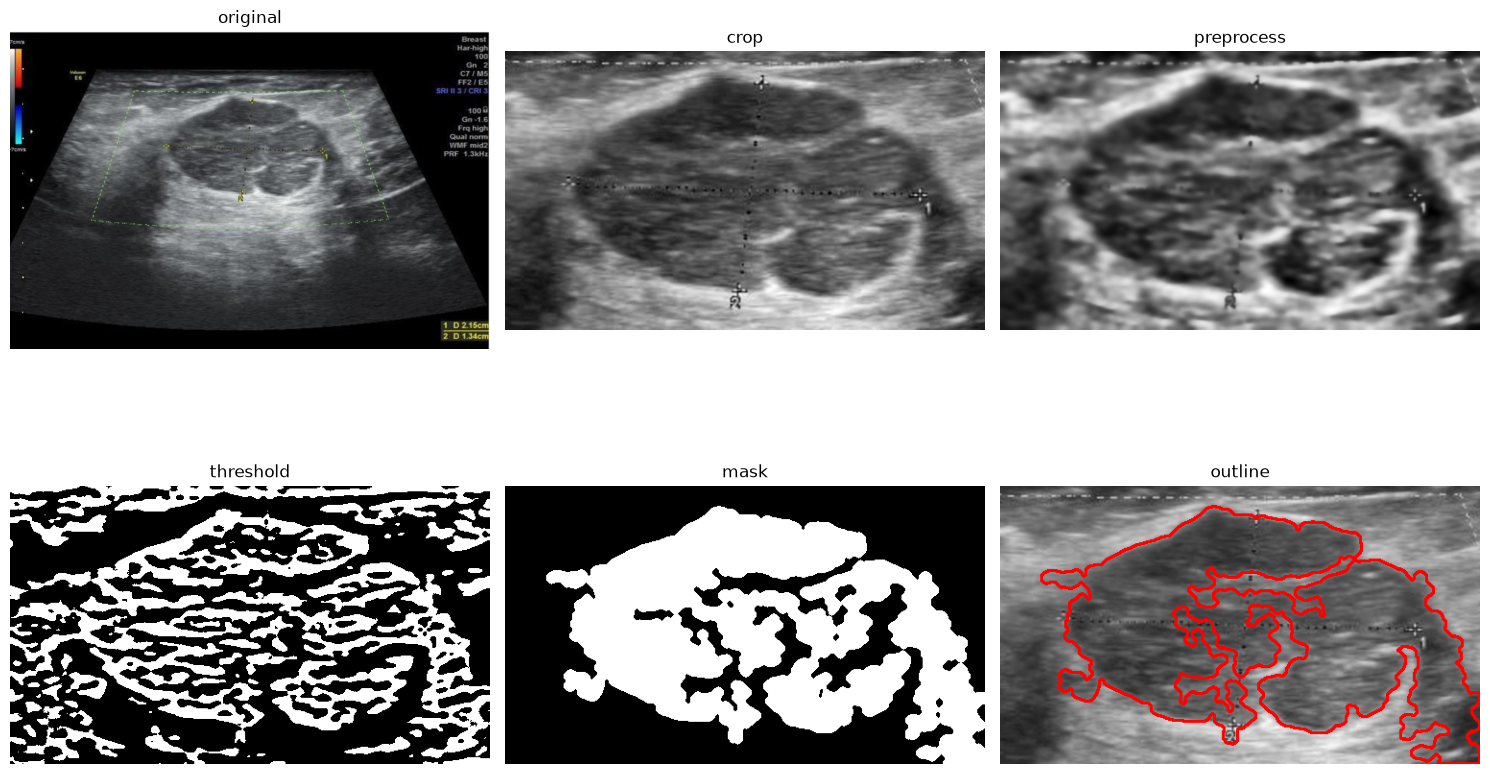

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

img = cv2.imread("tugas segmentasi.png", cv2.IMREAD_GRAYSCALE)
img_rgb = cv2.cvtColor(cv2.imread("tugas segmentasi.png"), cv2.COLOR_BGR2RGB)

# crop
y1, y2 = 130, 420
x1, x2 = 300, 800
roi = img[y1:y2, x1:x2]

# preprocessing
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
roi_clahe = clahe.apply(roi)
roi_bilateral = cv2.bilateralFilter(roi_clahe, 9, 75, 75)
roi_smooth = cv2.GaussianBlur(roi_bilateral, (3, 3), 0)

# threshold
_, mask_otsu = cv2.threshold(roi_smooth, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
mask_adaptive = cv2.adaptiveThreshold(roi_smooth, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 25, 3)
mask_combined = cv2.bitwise_and(mask_otsu, mask_adaptive)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 7))
mask_opened = cv2.morphologyEx(mask_combined, cv2.MORPH_OPEN, kernel, iterations=1)
mask_closed = cv2.morphologyEx(mask_opened, cv2.MORPH_CLOSE, kernel, iterations=2)
mask_filled = ndimage.binary_fill_holes(mask_closed).astype(np.uint8) * 255

# filter noise dan smoothing
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_filled)
mask_clean = np.zeros_like(mask_filled)
for i in range(1, num_labels):
    if stats[i, cv2.CC_STAT_AREA] >= 500:
        mask_clean[labels == i] = 255
contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest = max(contours, key=cv2.contourArea)
final_mask = np.zeros_like(mask_clean)
cv2.drawContours(final_mask, [largest], -1, 255, -1)
final_mask = ndimage.binary_fill_holes(final_mask).astype(np.uint8) * 255
kernel_expand = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
final_mask = cv2.dilate(final_mask, kernel_expand, iterations=1)
contours, _ = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
final_contour = [max(contours, key=cv2.contourArea)]

# outline
overlay = cv2.cvtColor(roi, cv2.COLOR_GRAY2RGB)
cv2.drawContours(overlay, final_contour, -1, (255, 0, 0), 2)

plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1); plt.imshow(img_rgb); plt.title("original"); plt.axis("off")
plt.subplot(2, 3, 2); plt.imshow(roi, cmap="gray"); plt.title("crop"); plt.axis("off")
plt.subplot(2, 3, 3); plt.imshow(roi_smooth, cmap="gray"); plt.title("preprocess"); plt.axis("off")
plt.subplot(2, 3, 4); plt.imshow(mask_combined, cmap="gray"); plt.title("threshold"); plt.axis("off")
plt.subplot(2, 3, 5); plt.imshow(final_mask, cmap="gray"); plt.title("mask"); plt.axis("off")
plt.subplot(2, 3, 6); plt.imshow(overlay); plt.title("outline"); plt.axis("off")
plt.tight_layout()
plt.show()
